# Denoise

# 1. Preparations
Before start, make sure that you choose
* Runtime Type = Python 3
* Hardware Accelerator = GPU

in the **Runtime** menu -> **Change runtime type**

Then, we clone the repository, set up the envrironment.

In [27]:
#  # Clone Real-ESRGAN and enter the Real-ESRGAN
#  !git clone https://github.com/xinntao/Real-ESRGAN.git
#  %cd Real-ESRGAN
#  # Set up the environment
#  !pip install basicsr
#  !pip install facexlib
#  !pip install gfpgan
#  !pip install -r requirements.txt
#  !python setup.py develop

# 2. Upload Images

Upload the images to be processed by Real-ESRGAN

In [28]:
import cv2

In [29]:
import os
import shutil
import tkinter as tk
from tkinter import filedialog

input_folder = '/home/vik0t/hackaton/test_images/'
result_folder = '/home/vik0t/hackaton/test_output/'

# Clean up existing directories
#if os.path.isdir(upload_folder):
#    shutil.rmtree(upload_folder)
if os.path.isdir(result_folder):
    shutil.rmtree(result_folder)

# Create new directories
# os.mkdir(upload_folder)
#os.mkdir(result_folder)

# Open file dialog to select images
#root = tk.Tk()
#root.withdraw()  # Hide the main window
#file_paths = filedialog.askopenfilenames(title="Select files to upload")#

# Move selected files to upload folder
#for file_path in file_paths:
#    filename = os.path.basename(file_path)
#    dst_path = os.path.join(upload_folder, filename)
#    print(f'Moving {filename} to {dst_path}')
#    shutil.move(file_path, dst_path)

print("File upload completed!")

File upload completed!


In [30]:
%cd Real-ESRGAN/

[Errno 2] No such file or directory: 'Real-ESRGAN/'
/home/vik0t/hackaton/Real-ESRGAN


# 3. Inference


In [31]:
# if it is out of memory, try to use the `--tile` option
# We upsample the image with the scale factor X3.5
!python inference_realesrgan.py -n RealESRGAN_x4plus -i '/home/vik0t/hackaton/test_images/' -o '/home/vik0t/hackaton/test_output/' --outscale 3.5 --face_enhance
# Arguments
# -n, --model_name: Model names
# -i, --input: input folder or image
# --outscale: Output scale, can be arbitrary scale factore.

/home/vik0t/hackaton/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vik0t/hackaton/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Testing 0 0a79f28c5bdb6b596f220377ade79bf2 copy
Testing 1 2b2586a5a935724899320c575d68ddfa
Testing 2 6e378ff39741328dd3b2239408caa67c


# 4. Visualization

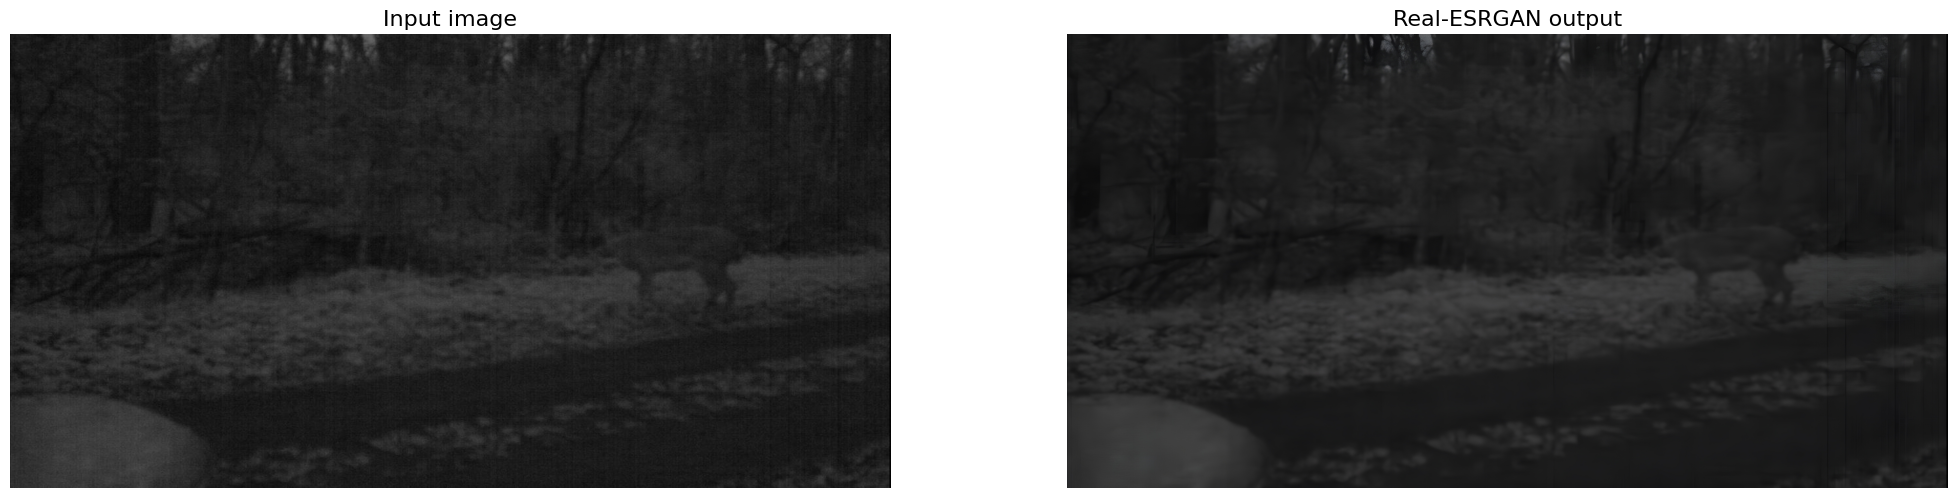

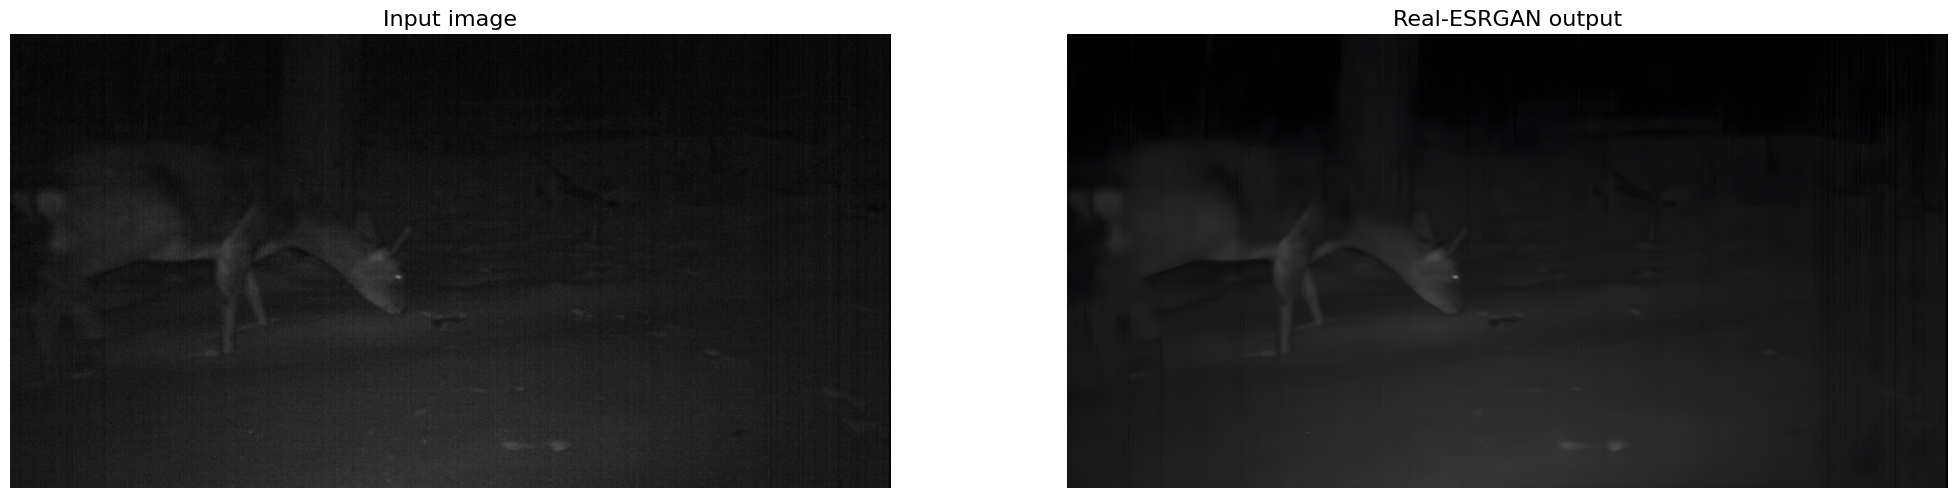

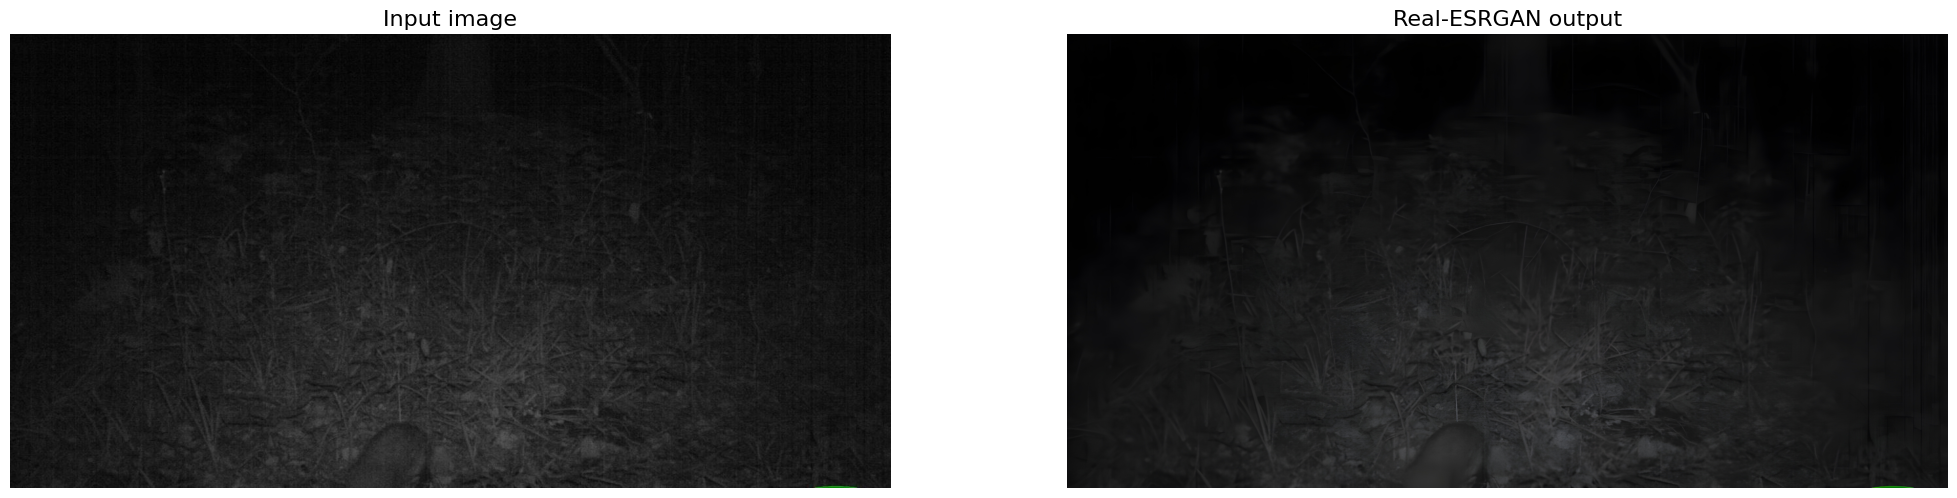

In [32]:
# utils for visualization
import cv2
import matplotlib.pyplot as plt
def display(img1, img2):
  fig = plt.figure(figsize=(25, 10))
  ax1 = fig.add_subplot(1, 2, 1)
  plt.title('Input image', fontsize=16)
  ax1.axis('off')
  ax2 = fig.add_subplot(1, 2, 2)
  plt.title('Real-ESRGAN output', fontsize=16)
  ax2.axis('off')
  ax1.imshow(img1)
  ax2.imshow(img2)
def imread(img_path):
  img = cv2.imread(img_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  return img

# display each image in the upload folder
import os
import glob

input_list = sorted(glob.glob(os.path.join(input_folder, '*')))
output_list = sorted(glob.glob(os.path.join(result_folder, '*')))
for input_path, output_path in zip(input_list, output_list):
  img_input = imread(input_path)
  img_output = imread(output_path)
  display(img_input, img_output)

# 5. Download Results
